**Install libraries**

In [ ]:
!pip install transformers datasets torch scikit-learn

**Import libraries**

In [ ]:
import torch
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

from transformers import AutoTokenizer, AutoModelForSequenceClassification

**Load Dataset**

In [ ]:
dataset = load_dataset("imdb")
df = dataset['train'].to_pandas()

# Reduce size for faster execution
df = df.sample(10000, random_state=42)

df.head()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

,text,label
6868,"Dumb is as dumb does, in this thoroughly unint...",0
24016,I dug out from my garage some old musicals and...,1
9668,After watching this movie I was honestly disap...,0
13640,This movie was nominated for best picture but ...,1
14018,Just like Al Gore shook us up with his painful...,1


**Data Preprocessing**

In [ ]:
import re
def clean_text(text):
  text = text.lower()
  text = re.sub(r'<.*?>', '', text) # Remove HTML
  text = re.sub(r'[^a-zA-Z]', ' ', text)
  return text
df['text'] = df['text'].apply(clean_text)

**Train, Validation and Test Split**

In [ ]:
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df['text'], df['label'], test_size=0.3, random_state=42
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels, test_size=0.5, random_state=42
)

**Tokenization**

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

train_encodings = tokenizer(list(train_texts), truncation = True, padding = True, max_length = 128)
val_encodings = tokenizer(list(val_texts), truncation = True, padding = True, max_length = 128)
test_encodings = tokenizer(list(test_texts), truncation = True, padding = True, max_length =128)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

**Create Dataset Class**

In [ ]:
class Dataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = list(labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = Dataset(train_encodings, train_labels)
val_dataset = Dataset(val_encodings, val_labels)
test_dataset = Dataset(test_encodings, test_labels)

**DataLoader**

In [ ]:
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size = 8, shuffle = True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size = 8)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size =8)

**Load BERT Model**

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels = 2)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

**Optimizer**

In [ ]:
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

**Training Function**

In [ ]:
def train_model(model, train_loader, val_loader, epochs=2):
    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for batch in train_loader:
            optimizer.zero_grad()

            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1} Loss: {total_loss}")

        evaluate(model, val_loader, "Validation")

**Evaluation Function**

In [ ]:
def evaluate(model, loader, name="Test"):
  model.eval()
  preds, true = [], []

  with torch.no_grad():
    for batch in loader:
      input_ids = batch['input_ids'].to(device)
      attention_mask = batch['attention_mask'].to(device)
      labels = batch['labels'].to(device)

      outputs = model(input_ids, attention_mask=attention_mask)
      predictions = torch.argmax(outputs.logits, dim =1)

      preds.extend(predictions.cpu().numpy())
      true.extend(labels.cpu().numpy())

  precision, recall, f1, _ = precision_recall_fscore_support(true, preds, average = "binary")
  acc = accuracy_score(true, preds)

  print(f"{name} Accuracy:", acc)
  print(f"{name} Precision:", precision)
  print(f"{name} Recall:", recall)
  print(f"{name} F1 Score:", f1)

  return acc, f1, preds, true

**Experiment 1: Full BERT**

In [ ]:
print("Training Full BERT...")
train_model(model, train_loader, val_loader)

acc_full, f1_full, preds, true = evaluate(model, test_loader, "Test")

Training Full BERT...
Epoch 1 Loss: 334.2760580871254
Validation Accuracy: 0.8846666666666667
Validation Precision: 0.8949579831932774
Validation Recall: 0.8670284938941656
Validation F1 Score: 0.8807718814610613
Epoch 2 Loss: 169.0503167337738
Validation Accuracy: 0.88
Validation Precision: 0.8961593172119487
Validation Recall: 0.8548168249660787
Validation F1 Score: 0.875
Test Accuracy: 0.886
Test Precision: 0.9014647137150466
Test Recall: 0.8746770025839793
Test F1 Score: 0.8878688524590164


**Confusion Matrix**

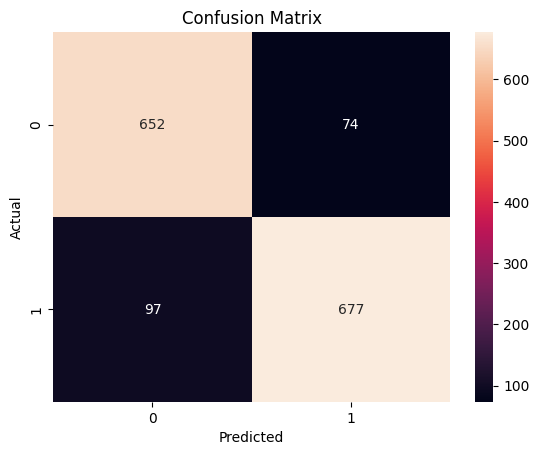

In [ ]:
cm = confusion_matrix(true, preds)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

**Experiment 2: Freeze BERT**

In [ ]:
model_frozen = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2).to(device)

for param in model_frozen.bert.parameters():
    param.requires_grad = False

optimizer = torch.optim.AdamW(model_frozen.parameters(), lr=2e-5)

print("Training Frozen BERT...")
train_model(model_frozen, train_loader, val_loader)

acc_frozen, f1_frozen, _, _ = evaluate(model_frozen, test_loader, "Test")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training Frozen BERT...
Epoch 1 Loss: 612.8791437149048
Validation Accuracy: 0.5606666666666666
Validation Precision: 0.5580357142857143
Validation Recall: 0.508819538670285
Validation F1 Score: 0.5322924059616749
Epoch 2 Loss: 600.1686000227928
Validation Accuracy: 0.59
Validation Precision: 0.558766859344894
Validation Recall: 0.7869742198100407
Validation F1 Score: 0.6535211267605634
Test Accuracy: 0.6013333333333334
Test Precision: 0.5838095238095238
Test Recall: 0.7919896640826873
Test F1 Score: 0.6721491228070176


**Experiment 3: Last 2 Layers**

In [ ]:
model_partial = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2).to(device)

for name, param in model_partial.bert.named_parameters():
    if "encoder.layer.10" in name or "encoder.layer.11" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

optimizer = torch.optim.AdamW(model_partial.parameters(), lr=2e-5)

print("Training Last 2 Layers...")
train_model(model_partial, train_loader, val_loader)

acc_partial, f1_partial, _, _ = evaluate(model_partial, test_loader, "Test")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training Last 2 Layers...
Epoch 1 Loss: 376.74730511009693
Validation Accuracy: 0.8486666666666667
Validation Precision: 0.909967845659164
Validation Recall: 0.76797829036635
Validation F1 Score: 0.8329654157468727
Epoch 2 Loss: 286.95051093772054
Validation Accuracy: 0.86
Validation Precision: 0.8986384266263238
Validation Recall: 0.8059701492537313
Validation F1 Score: 0.8497854077253219
Test Accuracy: 0.856
Test Precision: 0.8918539325842697
Test Recall: 0.8204134366925064
Test F1 Score: 0.8546433378196501


**Comparison Table**

In [ ]:
results = pd.DataFrame({
    "Model": ["Full BERT", "Frozen BERT", "Last 2 Layers"],
    "Accuracy": [acc_full, acc_frozen, acc_partial],
    "F1 Score": [f1_full, f1_frozen, f1_partial]
})

results

,Model,Accuracy,F1 Score
0,Full BERT,0.886000,0.887869
1,Frozen BERT,0.601333,0.672149
2,Last 2 Layers,0.856000,0.854643


**Final Analysis**

In [ ]:
print("Full BERT gives best performance.")
print("Frozen BERT is faster but less accurate.")
print("Last 2 layers provide balance between speed and performance.")

Full BERT gives best performance.
Frozen BERT is faster but less accurate.
Last 2 layers provide balance between speed and performance.
